# Stock Split Event Study
## Replication of Grinblatt, Masulis, and Titman (1984)

**Subperiods:** 1970–1999 and 2000–2024  
**Event definitions:** Announcement date (dclrdt) and Ex-date (exdt)  
**Model:** Constant Mean Return Model  
**Estimation window:** τ ∈ [4, 43] (post-event)

In [ ]:
## 0. Setup & Imports
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120
})

print('Setup complete.')

Setup complete.


## 1. Data Loading
### 1a. Load Split Events from CRSP `dsedist`

In [ ]:
db = wrds.Connection()

splits_query = """
    SELECT permno, dclrdt, exdt, distcd, facshr
    FROM crsp.dsedist
    WHERE distcd = 5523
      AND facshr > 0
      AND exdt BETWEEN '1970-01-01' AND '2024-12-31'
"""
splits_raw = db.raw_sql(splits_query)
print(f'Raw split events loaded: {len(splits_raw):,}')
splits_raw.head()

WRDS recommends setting up a .pgpass file.
pgpass file created at C:\Users\nkfav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Raw split events loaded: 16,248


,permno,dclrdt,exdt,distcd,facshr
0,10001,1994-05-18,1994-06-27,5523,1.0
1,10001,2008-02-05,2008-02-05,5523,0.5
2,10002,1998-05-12,1998-07-02,5523,0.5
3,10006,1976-03-05,1976-06-23,5523,0.5
4,10009,1995-07-31,1995-09-01,5523,1.0


In [ ]:
# ── Filter split events ──────────────────────────────────────
splits = splits_raw.copy()
splits.columns = splits.columns.str.lower().str.strip()

splits['dclrdt'] = pd.to_datetime(splits['dclrdt'])
splits['exdt']   = pd.to_datetime(splits['exdt'])

splits = splits[splits['distcd'] == 5523].copy()
splits = splits[splits['facshr'] > 0].copy()
splits = splits[['permno', 'dclrdt', 'exdt', 'facshr']].copy()
splits = splits.dropna(subset=['exdt'])

print(f'Split events after filtering: {len(splits):,}')
print(f'Events with missing dclrdt: {splits["dclrdt"].isna().sum():,}')
splits.describe()

Split events after filtering: 16,248
Events with missing dclrdt: 1,377


,permno,dclrdt,exdt,facshr
count,16248.0,14871,16248,16248.0
mean,54820.868415,1991-07-12 06:18:19.536009728,1992-02-04 15:36:25.524372224,0.882347
min,10001.0,1969-10-29 00:00:00,1970-01-13 00:00:00,0.005
25%,32521.0,1983-05-04 00:00:00,1983-07-17 06:00:00,0.5
50%,58683.0,1990-05-22 00:00:00,1991-11-18 00:00:00,1.0
75%,78044.0,1998-06-15 12:00:00,1998-09-10 06:00:00,1.0
max,93436.0,2024-12-17 00:00:00,2024-12-26 00:00:00,49.0
std,25578.004574,NaN,NaN,1.081344


### 1b. Load Daily Returns from CRSP `dsf`

In [ ]:
target_permnos = tuple(splits_raw['permno'].unique().tolist())

dsf_query = f"""
    SELECT a.permno, a.date, a.ret, b.shrcd, b.exchcd
    FROM crsp.dsf AS a
    LEFT JOIN crsp.msenames AS b
      ON a.permno = b.permno
      AND a.date BETWEEN b.namedt AND b.nameendt
    WHERE a.permno in {target_permnos}
      AND a.date BETWEEN '1969-01-01' AND '2025-06-30'
      AND b.exchcd IN (1, 2, 3)
      AND b.shrcd IN (10, 11)
"""
dsf_raw = db.raw_sql(dsf_query)
print(f'Raw daily return observations loaded: {len(dsf_raw):,}')
dsf_raw.head()

Raw daily return observations loaded: 34,570,833


,permno,date,ret,shrcd,exchcd
0,10001,1986-01-09,<NA>,11,3
1,10001,1986-01-10,0.021739,11,3
2,10001,1986-01-13,0.0,11,3
3,10001,1986-01-14,0.0,11,3
4,10001,1986-01-15,0.031915,11,3


In [ ]:
# ── Clean daily returns ──────────────────────────────────────
dsf = dsf_raw.copy()
dsf.columns = dsf.columns.str.lower().str.strip()
dsf['date'] = pd.to_datetime(dsf['date'])

dsf = dsf[dsf['exchcd'].isin([1, 2, 3])].copy()
dsf = dsf[dsf['shrcd'].isin([10, 11])].copy()
dsf['ret'] = pd.to_numeric(dsf['ret'], errors='coerce')
dsf = dsf.dropna(subset=['ret'])

print(f'Daily returns after filtering: {len(dsf):,}')
print(f'Unique permnos: {dsf["permno"].nunique():,}')
print(f'Date range: {dsf["date"].min()} to {dsf["date"].max()}')

Daily returns after filtering: 34,447,750
Unique permnos: 6,781
Date range: 1969-01-02 00:00:00 to 2024-12-31 00:00:00


---
## 2. Exploratory Data Analysis (EDA)
### 2.1 Splits Over Time (Using Ex-Date)

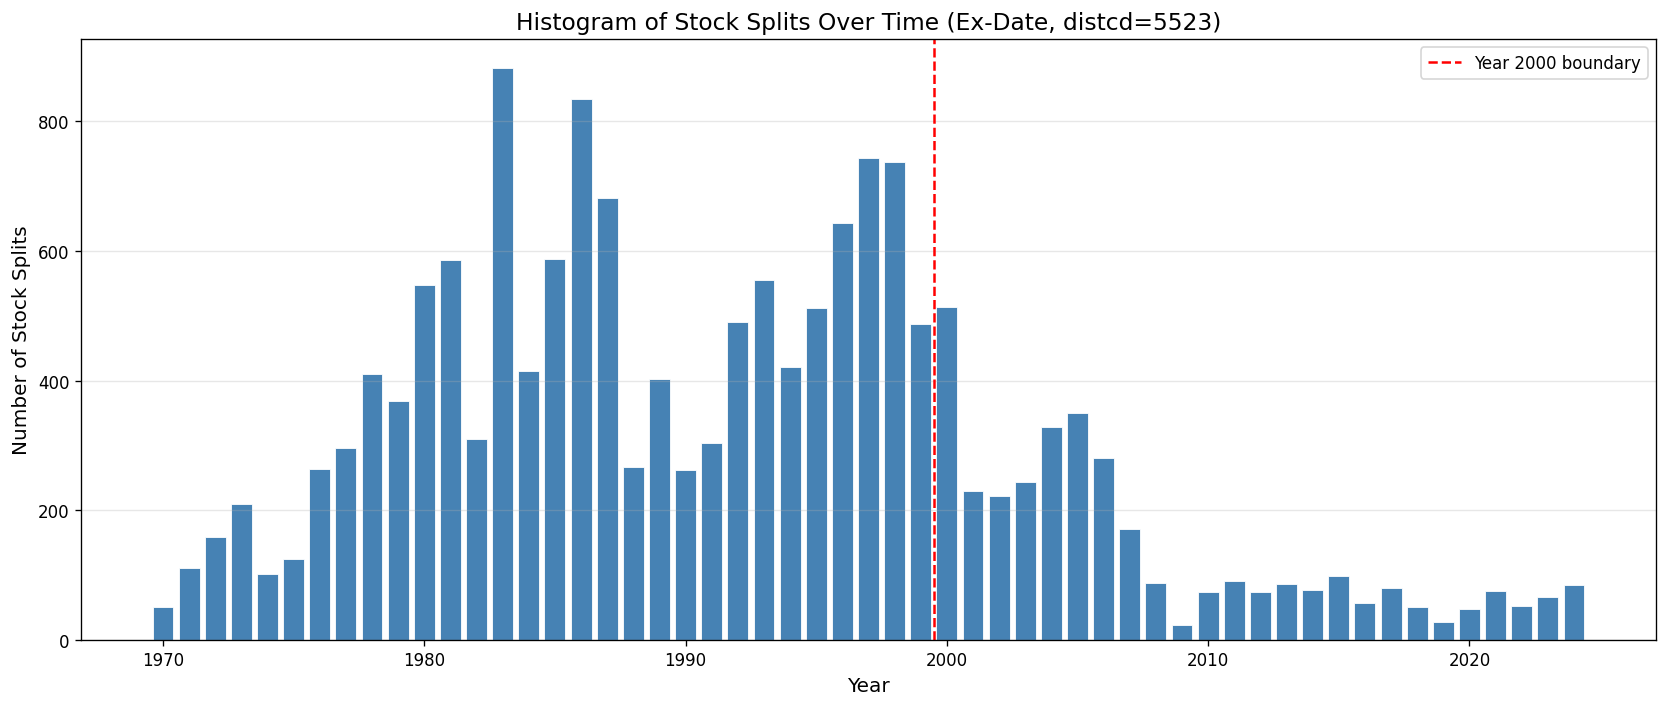


--- Splits Summary ---
1970-1999: Total = 12,762, Mean/year = 425.4, Median = 412
2000-2024: Total = 3,486, Mean/year = 139.4, Median = 84


In [ ]:
splits['ex_year'] = splits['exdt'].dt.year
splits_per_year = splits.groupby('ex_year').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(splits_per_year['ex_year'], splits_per_year['count'],
       color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(x=1999.5, color='red', linestyle='--', linewidth=1.5, label='Year 2000 boundary')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Stock Splits')
ax.set_title('Histogram of Stock Splits Over Time (Ex-Date, distcd=5523)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('splits_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

pre2000  = splits_per_year[splits_per_year['ex_year'] <= 1999]['count']
post2000 = splits_per_year[splits_per_year['ex_year'] >= 2000]['count']
print(f'\n--- Splits Summary ---')
print(f'1970-1999: Total = {pre2000.sum():,}, Mean/year = {pre2000.mean():.1f}, Median = {pre2000.median():.0f}')
print(f'2000-2024: Total = {post2000.sum():,}, Mean/year = {post2000.mean():.1f}, Median = {post2000.median():.0f}')

### 2.2 Announcement Clustering

In [ ]:
ann_dates = splits.dropna(subset=['dclrdt']).copy()
ann_counts = ann_dates.groupby('dclrdt').size().reset_index(name='count')
ann_counts = ann_counts.sort_values('count', ascending=False)

print('Top 10 announcement dates by number of splits:')
print(ann_counts.head(10).to_string(index=False))

top_date = ann_counts.iloc[0]
print(f'\nMost clustered date: {top_date["dclrdt"]} with {top_date["count"]} announcements')

print(f'\n--- Clustering Summary ---')
print(f'Total unique announcement dates: {len(ann_counts):,}')
print(f'Mean announcements per date: {ann_counts["count"].mean():.2f}')
print(f'Median: {ann_counts["count"].median():.0f}')
print(f'Dates with 5+ announcements: {(ann_counts["count"] >= 5).sum()}')

Top 10 announcement dates by number of splits:
    dclrdt  count
1989-10-18     35
2024-09-25     20
2008-07-11     17
2023-06-30     14
1986-04-15     14
1998-04-28     14
2005-05-25     14
1986-04-17     14
1983-05-04     13
2015-05-08     12

Most clustered date: 1989-10-18 00:00:00 with 35 announcements

--- Clustering Summary ---
Total unique announcement dates: 6,835
Mean announcements per date: 2.18
Median: 2
Dates with 5+ announcements: 596


---
## 3. Construct Event Datasets

Two separate event datasets:
1. **Event = Announcement date (`dclrdt`)**
2. **Event = Ex-date (`exdt`)**

Each split into subperiods: 1970–1999 and 2000–2024.

In [ ]:
# ── Build event datasets ─────────────────────────────────────
events_ann = splits.dropna(subset=['dclrdt'])[['permno', 'dclrdt']].copy()
events_ann = events_ann.rename(columns={'dclrdt': 'event_date'})
events_ann['event_type'] = 'announcement'

events_ex = splits[['permno', 'exdt']].copy()
events_ex = events_ex.rename(columns={'exdt': 'event_date'})
events_ex['event_type'] = 'exdate'

def assign_subperiod(df):
    df = df.copy()
    df['subperiod'] = np.where(df['event_date'] < '2000-01-01', '1970-1999', '2000-2024')
    return df

events_ann = assign_subperiod(events_ann)
events_ex  = assign_subperiod(events_ex)

events_all = pd.concat([events_ann, events_ex], ignore_index=True)
events_all['event_id'] = range(len(events_all))

print('Event counts:')
print(events_all.groupby(['event_type', 'subperiod']).size().unstack(fill_value=0))
print(f'\nTotal events: {len(events_all):,}')

Event counts:
subperiod     1970-1999  2000-2024
event_type                        
announcement      11795       3076
exdate            12762       3486

Total events: 31,119


---
## 4. Event Panel Construction

For each firm-event, keep:
- 40 trading days before (τ = −40 to −1)
- Event day (τ = 0)
- 43 trading days after (τ = 1 to 43)

Post-event window **[4, 43]** used for estimation (constant mean model).

In [ ]:
# ============================================================
# 4. Event Panel Construction (Memory-Efficient)
# ============================================================
# Process one permno at a time to avoid massive intermediate merges.

def build_event_panel_chunked(events_df, returns_df, pre_days=40, post_days=43):
    """
    Memory-efficient panel construction: loops over permnos, not rows.
    """
    ret = returns_df.sort_values(['permno', 'date']).copy()
    ret['td_idx'] = ret.groupby('permno').cumcount()

    evts = events_df[['event_id', 'permno', 'event_date', 'event_type', 'subperiod']].copy()

    panels = []
    permnos_with_events = evts['permno'].unique()
    total = len(permnos_with_events)

    for i, perm in enumerate(permnos_with_events):
        if (i + 1) % 2000 == 0:
            print(f'  Processing permno {i+1:,}/{total:,}...')

        # Get this firm's returns and events
        firm_ret = ret[ret['permno'] == perm][['date', 'ret', 'td_idx']].copy()
        firm_evts = evts[evts['permno'] == perm].copy()

        if len(firm_ret) == 0:
            continue

        # For each event, find the matching trading day
        firm_ret_sorted = firm_ret.sort_values('date')

        for _, evt in firm_evts.iterrows():
            # Find first trading day >= event_date
            mask = firm_ret_sorted['date'] >= evt['event_date']
            if not mask.any():
                continue

            event_td = firm_ret_sorted.loc[mask, 'td_idx'].iloc[0]

            # Extract window
            td_min = event_td - pre_days
            td_max = event_td + post_days
            window = firm_ret_sorted[
                (firm_ret_sorted['td_idx'] >= td_min) &
                (firm_ret_sorted['td_idx'] <= td_max)
            ].copy()

            if len(window) < 20:  # skip if too few days
                continue

            window['tau'] = window['td_idx'] - event_td
            window['event_id'] = evt['event_id']
            window['permno'] = perm
            window['event_date'] = evt['event_date']
            window['event_type'] = evt['event_type']
            window['subperiod'] = evt['subperiod']

            panels.append(window[['event_id', 'permno', 'date', 'ret', 'tau',
                                  'event_date', 'event_type', 'subperiod']])

    panel = pd.concat(panels, ignore_index=True)
    return panel

print('Building event panels (memory-efficient)... this may take 10-20 minutes.')
panel = build_event_panel_chunked(events_all, dsf, pre_days=40, post_days=43)

print(f'\nPanel built successfully!')
print(f'Total observations: {len(panel):,}')
print(f'Unique events: {panel["event_id"].nunique():,}')
print(f'\nEvents by type and subperiod:')
print(panel.groupby(['event_type', 'subperiod'])['event_id'].nunique())

Building event panels (memory-efficient)... this may take 10-20 minutes.
  Processing permno 2,000/7,746...
  Processing permno 4,000/7,746...
  Processing permno 6,000/7,746...

Panel built successfully!
Total observations: 2,395,949
Unique events: 28,627

Events by type and subperiod:
event_type    subperiod
announcement  1970-1999    11410
              2000-2024     2408
exdate        1970-1999    12173
              2000-2024     2636
Name: event_id, dtype: int64


---
## 5. Quality Checks on Panel

In [ ]:
event_coverage = panel.groupby('event_id')['tau'].agg(['min', 'max', 'count'])
print("Event coverage summary:")
print(event_coverage.describe())

# Keep events with sufficient coverage
full_events = event_coverage[
    (event_coverage['min'] <= -40) &
    (event_coverage['max'] >= 43) &
    (event_coverage['count'] >= 80)
].index

print(f'\nEvents with sufficient coverage: {len(full_events):,} / {panel["event_id"].nunique():,}')

panel = panel[panel['event_id'].isin(full_events)].copy()
print(f'Panel after filtering: {len(panel):,} obs, {panel["event_id"].nunique():,} events')
print(panel.groupby(['event_type', 'subperiod'])['event_id'].nunique())

Event coverage summary:
                min           max         count
count  28627.000000  28627.000000  28627.000000
mean     -39.722919     42.972508     83.695427
std        3.014104      0.885962      3.143194
min      -40.000000      0.000000     41.000000
25%      -40.000000     43.000000     84.000000
50%      -40.000000     43.000000     84.000000
75%      -40.000000     43.000000     84.000000
max        0.000000     43.000000     84.000000

Events with sufficient coverage: 28,287 / 28,627
Panel after filtering: 2,376,108 obs, 28,287 events
event_type    subperiod
announcement  1970-1999    11254
              2000-2024     2380
exdate        1970-1999    12049
              2000-2024     2604
Name: event_id, dtype: int64


---
## 6. Compute Abnormal Returns (Constant Mean Model)

**Estimation window:** τ ∈ [4, 43] (post-event, L₁ = 40 days)

For each firm-event *i*:
- Expected return: R̄ᵢ = (1/L₁) Σ Rᵢτ for τ ∈ [4, 43]
- Abnormal return: ARᵢτ = Rᵢτ − R̄ᵢ
- Residual variance: σ̂²ᵢ = (1/(L₁−1)) Σ (Rᵢτ − R̄ᵢ)² for τ ∈ [4, 43]

In [ ]:
EST_START = 4
EST_END   = 43
L1        = EST_END - EST_START + 1  # 40

# Step 1: Expected return and variance from estimation window
est_window = panel[(panel['tau'] >= EST_START) & (panel['tau'] <= EST_END)].copy()

est_stats = est_window.groupby('event_id')['ret'].agg(
    mean_ret='mean',
    var_ret='var',       # sample variance (ddof=1)
    n_est='count'
).reset_index()

# Require at least 30 of 40 estimation-window days
est_stats = est_stats[est_stats['n_est'] >= 30].copy()
print(f'Events with valid estimation window: {len(est_stats):,}')

# Step 2: Merge and compute AR
panel = panel.merge(est_stats[['event_id', 'mean_ret', 'var_ret', 'n_est']],
                     on='event_id', how='inner')

panel['ar'] = panel['ret'] - panel['mean_ret']

print(f'Panel with AR: {len(panel):,} obs, {panel["event_id"].nunique():,} events')
print(f'\nEvents by group:')
print(panel.groupby(['event_type', 'subperiod'])['event_id'].nunique())

Events with valid estimation window: 28,287
Panel with AR: 2,376,108 obs, 28,287 events

Events by group:
event_type    subperiod
announcement  1970-1999    11254
              2000-2024     2380
exdate        1970-1999    12049
              2000-2024     2604
Name: event_id, dtype: int64


---
## 7. Cumulative Abnormal Returns (CAR)

CARᵢ(τ₁, τ₂) = Σ ARᵢτ from τ₁ to τ₂

In [ ]:
panel = panel.sort_values(['event_id', 'tau']).reset_index(drop=True)
panel['car'] = panel.groupby('event_id')['ar'].cumsum()

print('CAR computed. Sample for first event:')
sample_id = panel['event_id'].iloc[0]
print(panel[panel['event_id'] == sample_id][['tau', 'ret', 'mean_ret', 'ar', 'car']].head(15))

CAR computed. Sample for first event:
    tau       ret  mean_ret        ar       car
0   -40       0.0  0.004497 -0.004497 -0.004497
1   -39  0.014493  0.004497  0.009996    0.0055
2   -38       0.0  0.004497 -0.004497  0.001003
3   -37 -0.014286  0.004497 -0.018783 -0.017779
4   -36  0.014493  0.004497  0.009996 -0.007783
5   -35 -0.014286  0.004497 -0.018783 -0.026565
6   -34  0.007246  0.004497  0.002749 -0.023816
7   -33       0.0  0.004497 -0.004497 -0.028312
8   -32 -0.007194  0.004497 -0.011691 -0.040003
9   -31 -0.028986  0.004497 -0.033483 -0.073486
10  -30  0.014925  0.004497  0.010428 -0.063057
11  -29 -0.007353  0.004497  -0.01185 -0.074907
12  -28  0.007407  0.004497   0.00291 -0.071996
13  -27 -0.007353  0.004497  -0.01185 -0.083846
14  -26  0.007407  0.004497   0.00291 -0.080935


---
## 8. AAR, CAAR, Standard Errors, and t-Statistics

- AAR_τ = (1/N_τ) Σ ARᵢτ
- Var(ARᵢτ) = σ̂²ᵢ (1 + 1/L₁)  — prediction-error adjustment
- SE(AAR_τ) = √[ (1/N²_τ) Σ σ̂²ᵢ (1 + 1/L₁) ]
- t_τ = AAR_τ / SE(AAR_τ)
- CAAR(τ₁, τ₂) = Σ AAR_τ

In [ ]:
def compute_event_study_stats(panel_df, label=''):
    """Compute AAR, CAAR, SE, t-stats for a panel subset."""
    adj = 1 + 1 / L1  # prediction-error adjustment (1.025)

    results = []
    for tau_val, grp in panel_df.groupby('tau'):
        n_tau = len(grp)
        aar = grp['ar'].mean()

        # SE(AAR) using firm-specific variances with prediction-error adjustment
        se_aar = np.sqrt((1 / n_tau**2) * (grp['var_ret'] * adj).sum())
        t_stat = aar / se_aar if se_aar > 0 else np.nan

        results.append({
            'tau': tau_val, 'aar': aar, 'se_aar': se_aar,
            't_stat': t_stat, 'n_events': n_tau
        })

    stats = pd.DataFrame(results).sort_values('tau').reset_index(drop=True)

    # CAAR = cumulative sum of AAR
    stats['caar'] = stats['aar'].cumsum()

    # CAAR SE (cumulative variance, independence across tau)
    stats['var_caar'] = (stats['se_aar']**2).cumsum()
    stats['se_caar']  = np.sqrt(stats['var_caar'])
    stats['t_caar']   = stats['caar'] / stats['se_caar']

    stats['label'] = label
    return stats

# Compute for all four groups
all_stats = []
for (etype, subp), grp in panel.groupby(['event_type', 'subperiod']):
    label = f'{etype} | {subp}'
    stats = compute_event_study_stats(grp, label=label)
    stats['event_type'] = etype
    stats['subperiod']  = subp
    all_stats.append(stats)
    n_ev = grp['event_id'].nunique()
    print(f'{label}: {n_ev:,} events, tau [{stats["tau"].min():.0f}, {stats["tau"].max():.0f}]')

stats_all = pd.concat(all_stats, ignore_index=True)
print(f'\nDone — stats computed for {len(all_stats)} groups.')

announcement | 1970-1999: 11,254 events, tau [-40, 43]
announcement | 2000-2024: 2,380 events, tau [-40, 43]
exdate | 1970-1999: 12,049 events, tau [-40, 43]
exdate | 2000-2024: 2,604 events, tau [-40, 43]

Done — stats computed for 4 groups.


---
## 9. CAAR Plots by Subperiod (2 panels with difference line)

Both subperiods overlaid per event type, with a difference line (1970–1999 minus 2000–2024).

In [ ]:
# Compute median trading-day lag between declaration date and ex-date
lag_cal = (splits.dropna(subset=['dclrdt'])['exdt'] -
           splits.dropna(subset=['dclrdt'])['dclrdt']).dt.days
median_lag_td = int(round(lag_cal.median() * 252 / 365))
print(f'Median lag dclrdt → exdt: {lag_cal.median():.0f} calendar days ≈ {median_lag_td} trading days')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cumulative Average Abnormal Returns (CAAR) Around Stock Splits\nBy Subperiod with Difference Line',
             fontsize=15, fontweight='bold')

plot_configs = [
    ('announcement', 'Declaration Date (dclrdt)', axes[0]),
    ('exdate',       'Ex-Date (exdt)',             axes[1]),
]

for etype, event_label, ax in plot_configs:
    d1 = stats_all[(stats_all['event_type'] == etype) & (stats_all['subperiod'] == '1970-1999')].set_index('tau')
    d2 = stats_all[(stats_all['event_type'] == etype) & (stats_all['subperiod'] == '2000-2024')].set_index('tau')
    common_tau = d1.index.intersection(d2.index)
    d1, d2 = d1.loc[common_tau], d2.loc[common_tau]
    diff = (d1['caar'] - d2['caar']) * 100
    n1, n2 = int(d1['n_events'].iloc[0]), int(d2['n_events'].iloc[0])

    ax.plot(common_tau, d1['caar'] * 100, color='steelblue', linewidth=1.3,
            label=f'1970–1999 (N={n1:,})')
    ax.fill_between(common_tau,
                    (d1['caar'] - 1.96 * d1['se_caar']) * 100,
                    (d1['caar'] + 1.96 * d1['se_caar']) * 100,
                    alpha=0.12, color='steelblue')
    ax.plot(common_tau, d2['caar'] * 100, color='darkorange', linewidth=1.3,
            label=f'2000–2024 (N={n2:,})')
    ax.fill_between(common_tau,
                    (d2['caar'] - 1.96 * d2['se_caar']) * 100,
                    (d2['caar'] + 1.96 * d2['se_caar']) * 100,
                    alpha=0.12, color='darkorange')
    ax.plot(common_tau, diff, color='black', linewidth=1.3, linestyle='--',
            label='Difference (1970–99 minus 2000–24)')

    ax.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='τ = 0')
    if etype == 'announcement':
        ax.axvline(x=median_lag_td, color='green', linestyle=':', linewidth=1.1,
                   label=f'Avg Ex-Date (τ≈+{median_lag_td})')
    else:
        ax.axvline(x=-median_lag_td, color='green', linestyle=':', linewidth=1.1,
                   label=f'Avg Decl. Date (τ≈-{median_lag_td})')

    ax.set_title(f'{event_label}', fontsize=12)
    ax.set_xlabel('Event Day (τ)')
    ax.set_ylabel('CAAR (%)')
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('caar_plots_2panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('CAAR 2-panel plot saved.')

## 10. Individual CAAR Plots (publication quality, with 95% CI)

In [ ]:
for etype, event_label in [('announcement', 'Declaration Date (dclrdt)'), ('exdate', 'Ex-Date (exdt)')]:
    d1 = stats_all[(stats_all['event_type'] == etype) & (stats_all['subperiod'] == '1970-1999')].set_index('tau')
    d2 = stats_all[(stats_all['event_type'] == etype) & (stats_all['subperiod'] == '2000-2024')].set_index('tau')
    common_tau = d1.index.intersection(d2.index)
    d1, d2 = d1.loc[common_tau], d2.loc[common_tau]
    diff = (d1['caar'] - d2['caar']) * 100
    n1, n2 = int(d1['n_events'].iloc[0]), int(d2['n_events'].iloc[0])

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(common_tau, d1['caar'] * 100, color='steelblue', linewidth=1.5,
            label=f'1970–1999 (N={n1:,})')
    ax.fill_between(common_tau,
                    (d1['caar'] - 1.96 * d1['se_caar']) * 100,
                    (d1['caar'] + 1.96 * d1['se_caar']) * 100,
                    alpha=0.12, color='steelblue', label='95% CI (1970–1999)')
    ax.plot(common_tau, d2['caar'] * 100, color='darkorange', linewidth=1.5,
            label=f'2000–2024 (N={n2:,})')
    ax.fill_between(common_tau,
                    (d2['caar'] - 1.96 * d2['se_caar']) * 100,
                    (d2['caar'] + 1.96 * d2['se_caar']) * 100,
                    alpha=0.12, color='darkorange', label='95% CI (2000–2024)')
    ax.plot(common_tau, diff, color='black', linewidth=1.5, linestyle='--',
            label='Difference (1970–1999 minus 2000–2024)')

    ax.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='τ = 0 (event date)')
    if etype == 'announcement':
        ax.axvline(x=median_lag_td, color='green', linestyle=':', linewidth=1.2,
                   label=f'Avg Ex-Date (τ≈+{median_lag_td})')
    else:
        ax.axvline(x=-median_lag_td, color='green', linestyle=':', linewidth=1.2,
                   label=f'Avg Decl. Date (τ≈-{median_lag_td})')

    ax.set_title(f'Stock Splits ({event_label}) | CAAR by Subperiod\n'
                 f'Constant Mean Model | Est. Window [4, 43]', fontsize=13)
    ax.set_xlabel('Event Day (τ)')
    ax.set_ylabel('Cumulative Abnormal Return (%)')
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

    fname = f'caar_{etype}_subperiod_comparison.png'
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

---
## 11. AAR Tables (τ ∈ [−10, 10])

Four tables: one per event type × subperiod.  
Reports AAR (%), standard error, t-statistic, and significance.

In [ ]:
def format_aar_table(stats_df, event_type, subperiod):
    """Format AAR table for τ ∈ [-10, 10]."""
    mask = (
        (stats_df['event_type'] == event_type) &
        (stats_df['subperiod'] == subperiod) &
        (stats_df['tau'] >= -10) &
        (stats_df['tau'] <= 10)
    )
    tbl = stats_df[mask][['tau', 'aar', 'se_aar', 't_stat', 'n_events']].copy()
    tbl = tbl.sort_values('tau').reset_index(drop=True)

    tbl['AAR (%)'] = tbl['aar'] * 100
    tbl['SE (%)']  = tbl['se_aar'] * 100
    tbl['t-stat']  = tbl['t_stat']
    tbl['N']       = tbl['n_events']
    tbl['τ']       = tbl['tau'].astype(int)

    def stars(t):
        a = abs(t)
        if a >= 2.576: return '***'
        if a >= 1.960: return '**'
        if a >= 1.645: return '*'
        return ''

    tbl['sig'] = tbl['t-stat'].apply(stars)

    out = tbl[['τ', 'AAR (%)', 'SE (%)', 't-stat', 'sig', 'N']].copy()
    out['AAR (%)'] = out['AAR (%)'].map('{:.4f}'.format)
    out['SE (%)']  = out['SE (%)'].map('{:.4f}'.format)
    out['t-stat']  = out['t-stat'].map('{:.2f}'.format)
    return out

for etype, subp in table_configs:
    event_label = 'Announcement (dclrdt)' if etype == 'announcement' else 'Ex-Date (exdt)'
    print(f'\n{"="*70}')
    print(f'AAR Table: {event_label} | {subp}')
    print(f'{"="*70}')
    tbl = format_aar_table(stats_all, etype, subp)
    print(tbl.to_string(index=False))
    print('Significance: *** p<0.01, ** p<0.05, * p<0.10')


AAR Table: Announcement (dclrdt) | 1970-1999
  τ AAR (%) SE (%) t-stat sig     N
-10  0.2452 0.0299   8.19 *** 11254
 -9  0.2168 0.0299   7.24 *** 11254
 -8  0.3029 0.0299  10.12 *** 11254
 -7  0.2144 0.0299   7.16 *** 11254
 -6  0.2490 0.0299   8.32 *** 11254
 -5  0.2407 0.0299   8.04 *** 11254
 -4  0.2000 0.0299   6.68 *** 11254
 -3  0.2535 0.0299   8.47 *** 11254
 -2  0.3094 0.0299  10.33 *** 11254
 -1  0.3486 0.0299  11.64 *** 11254
  0  1.5978 0.0299  53.36 *** 11254
  1  1.1591 0.0299  38.71 *** 11254
  2  0.4272 0.0299  14.27 *** 11254
  3  0.1213 0.0299   4.05 *** 11254
  4  0.0628 0.0299   2.10  ** 11254
  5  0.0357 0.0299   1.19     11254
  6  0.0507 0.0299   1.69   * 11254
  7 -0.0137 0.0299  -0.46     11254
  8 -0.0350 0.0299  -1.17     11254
  9 -0.0197 0.0299  -0.66     11254
 10  0.0170 0.0299   0.57     11254
Significance: *** p<0.01, ** p<0.05, * p<0.10

AAR Table: Announcement (dclrdt) | 2000-2024
  τ AAR (%) SE (%) t-stat sig    N
-10  0.2340 0.0773   3.03 *** 2380


---
## 12. Summary Statistics & Sanity Checks

In [ ]:
print('=' * 60)
print('EVENT STUDY SUMMARY')
print('=' * 60)

for etype, subp in table_configs:
    mask = (stats_all['event_type'] == etype) & (stats_all['subperiod'] == subp)
    data = stats_all[mask].copy()
    if len(data) == 0:
        continue

    event_label = 'Announcement' if etype == 'announcement' else 'Ex-Date'
    n = data['n_events'].iloc[0]

    caar_m1_p1  = data[data['tau'].between(-1, 1)]['aar'].sum() * 100
    caar_m10_10 = data[data['tau'].between(-10, 10)]['aar'].sum() * 100
    aar_0 = data[data['tau'] == 0]['aar'].values[0] * 100
    t_0   = data[data['tau'] == 0]['t_stat'].values[0]
    full_caar = data['aar'].sum() * 100

    print(f'\n--- {event_label} | {subp} (N={n:,}) ---')
    print(f'  AAR at τ=0:      {aar_0:+.4f}%  (t = {t_0:.2f})')
    print(f'  CAAR[-1, +1]:    {caar_m1_p1:+.4f}%')
    print(f'  CAAR[-10, +10]:  {caar_m10_10:+.4f}%')
    print(f'  CAAR[-40, +40]:  {full_caar:+.4f}%')

print('\n' + '=' * 60)
print('Model: Constant Mean | Est. Window: τ ∈ [4, 43]')
print('=' * 60)

EVENT STUDY SUMMARY

--- Announcement | 1970-1999 (N=11,254) ---
  AAR at τ=0:      +1.5978%  (t = 53.36)
  CAAR[-1, +1]:    +3.1055%
  CAAR[-10, +10]:  +5.9836%
  CAAR[-40, +40]:  +11.7707%

--- Announcement | 2000-2024 (N=2,380) ---
  AAR at τ=0:      +1.2681%  (t = 16.41)
  CAAR[-1, +1]:    +2.6840%
  CAAR[-10, +10]:  +6.5920%
  CAAR[-40, +40]:  +13.9857%

--- Ex-Date | 1970-1999 (N=12,049) ---
  AAR at τ=0:      +1.4387%  (t = 46.89)
  CAAR[-1, +1]:    +2.3234%
  CAAR[-10, +10]:  +3.4165%
  CAAR[-40, +40]:  +11.5479%

--- Ex-Date | 2000-2024 (N=2,604) ---
  AAR at τ=0:      +0.6815%  (t = 8.45)
  CAAR[-1, +1]:    +0.8942%
  CAAR[-10, +10]:  +1.6111%
  CAAR[-40, +40]:  +10.9016%

Model: Constant Mean | Est. Window: τ ∈ [4, 43]


---
## 13. Export Results

In [ ]:
for etype, subp in table_configs:
    tag = 'ann' if etype == 'announcement' else 'exdt'
    tbl = format_aar_table(stats_all, etype, subp)
    fname = f'aar_table_{tag}_{subp.replace("-","_")}.csv'
    tbl.to_csv(fname, index=False)
    print(f'Saved: {fname}')

stats_all.to_csv('event_study_full_stats.csv', index=False)
print('\n✅ Event study complete!')

Saved: aar_table_ann_1970_1999.csv
Saved: aar_table_ann_2000_2024.csv
Saved: aar_table_exdt_1970_1999.csv
Saved: aar_table_exdt_2000_2024.csv

✅ Event study complete!
